In [9]:
from pathlib import Path

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [10]:
model = tf.keras.models.load_model("../models/best_efficientnet.keras")

In [11]:
DATA_DIR = Path("../data/raw/chest_xray")
TEST_DIR = DATA_DIR / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

class_names = test_ds.class_names

print("Classes:", class_names)

Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [12]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 282ms/step - accuracy: 0.8186 - loss: 0.5061
Test Accuracy: 0.8766
Test Loss: 0.3257


In [13]:
predictions = model.predict(test_ds)

predicted_labels = (predictions > 0.5).astype(int).flatten()

print(predicted_labels[:50])

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 294ms/step
[0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 1 1 1 0]


In [14]:
true_labels = np.concatenate(
    [labels.numpy() for images, labels in test_ds],
    axis=0
)

print("True label counts:")
print(np.unique(true_labels, return_counts=True))

manual_accuracy = np.mean(predicted_labels == true_labels)

print("\nManual accuracy:", manual_accuracy)
print("Manual accuracy %:", manual_accuracy * 100)

True label counts:
(array([0, 1], dtype=int32), array([234, 390]))

Manual accuracy: 0.8766025641025641
Manual accuracy %: 87.66025641025641


2026-08-04 15:22:02.206291: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
manual_accuracy = np.mean(predicted_labels == true_labels)

print("Manual accuracy:", manual_accuracy)
print("Manual accuracy %:", manual_accuracy * 100)

print("Predicted counts:", np.unique(predicted_labels, return_counts=True))
print("True counts:", np.unique(true_labels, return_counts=True))

Manual accuracy: 0.8766025641025641
Manual accuracy %: 87.66025641025641
Predicted counts: (array([0, 1]), array([191, 433]))
True counts: (array([0, 1], dtype=int32), array([234, 390]))


In [16]:
print("Prediction probability statistics:")

print("Minimum:", predictions.min())
print("Maximum:", predictions.max())
print("Mean:", predictions.mean())
print("Median:", np.median(predictions))

print("\nFirst 20 probabilities:")
print(predictions[:20].flatten())

Prediction probability statistics:
Minimum: 0.0007422403
Maximum: 0.99999315
Mean: 0.70019275
Median: 0.96926266

First 20 probabilities:
[0.25229973 0.04395087 0.27884832 0.05608596 0.15711197 0.01903985
 0.426459   0.6872188  0.87238675 0.07629663 0.06290367 0.82763845
 0.5156424  0.4809696  0.3031672  0.01289465 0.9978745  0.15014957
 0.10840099 0.40546632]


In [17]:
true_labels = np.concatenate([
    labels.numpy() for images, labels in test_ds
])

print(true_labels[:50])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

[[174  60]
 [ 17 373]]


In [19]:
for images, labels in test_ds.take(1):
    print(labels.numpy())

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


2026-08-04 15:22:02.620873: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [20]:
normal = 0
pneumonia = 0

for images, labels in test_ds:
    normal += np.sum(labels.numpy() == 0)
    pneumonia += np.sum(labels.numpy() == 1)

print("Normal:", normal)
print("Pneumonia:", pneumonia)

Normal: 234
Pneumonia: 390


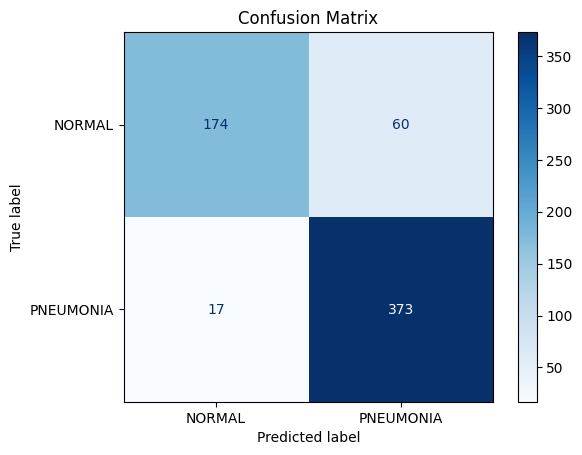

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

      NORMAL       0.91      0.74      0.82       234
   PNEUMONIA       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624



In [23]:
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
)

with open("../results/classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved!")

Classification report saved!


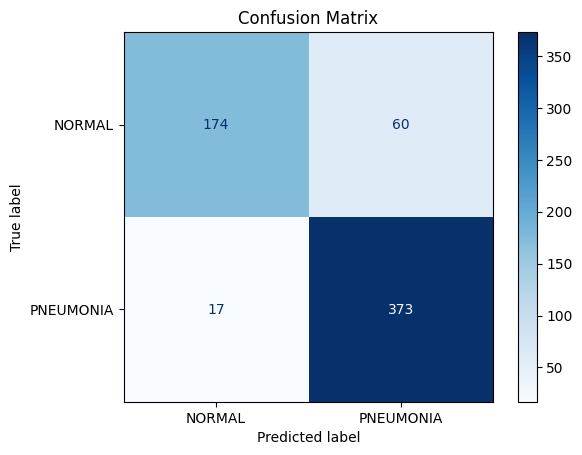

Confusion matrix saved!


In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "../results/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved!")

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

      NORMAL       0.91      0.74      0.82       234
   PNEUMONIA       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624



ROC-AUC: 0.9540


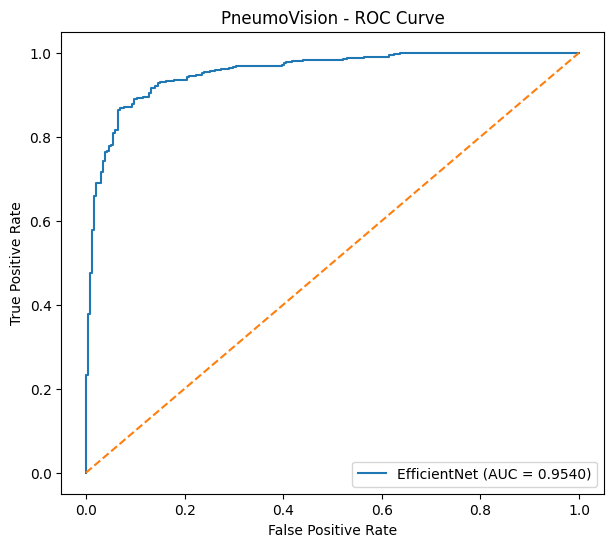

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC-AUC
auc = roc_auc_score(true_labels, predictions.flatten())

print(f"ROC-AUC: {auc:.4f}")

# ROC curve
fpr, tpr, thresholds = roc_curve(
    true_labels,
    predictions.flatten()
)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"EfficientNet (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PneumoVision - ROC Curve")
plt.legend()
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Find incorrect predictions
incorrect = np.where(predicted_labels != true_labels)[0]

print("Total incorrect predictions:", len(incorrect))
print("Total correct predictions:", len(true_labels) - len(incorrect))

Total incorrect predictions: 77
Total correct predictions: 547


In [28]:
# Collect all test images and labels
test_images = []
test_labels = []

for images, labels in test_ds:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels)

print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Test images shape: (624, 224, 224, 3)
Test labels shape: (624,)


False negatives: 17


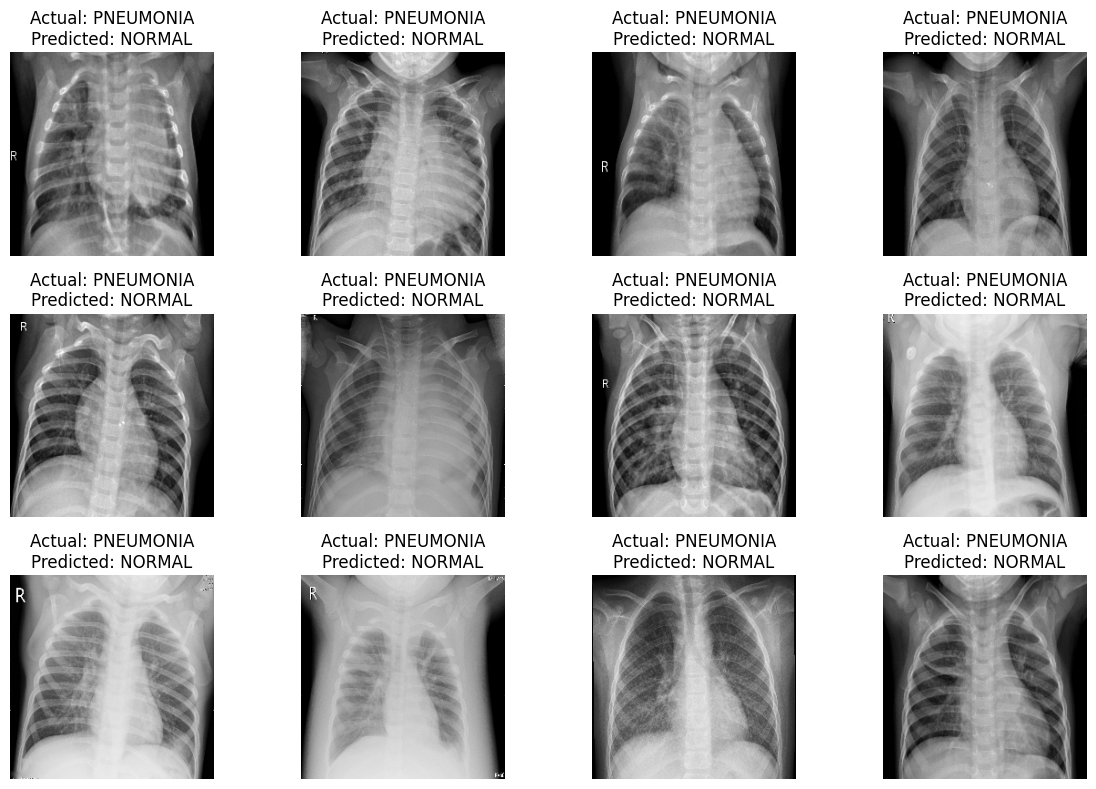

In [29]:
# False negatives:
# Actual pneumonia (1), predicted normal (0)

false_negatives = np.where(
    (true_labels == 1) & (predicted_labels == 0)
)[0]

print("False negatives:", len(false_negatives))

plt.figure(figsize=(12, 8))

for i, idx in enumerate(false_negatives[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[idx].astype("uint8"))
    plt.title(f"Actual: PNEUMONIA\nPredicted: NORMAL")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Calculate metrics
accuracy = accuracy_score(true_labels, predicted_labels)

precision = precision_score(
    true_labels,
    predicted_labels
)

recall = recall_score(
    true_labels,
    predicted_labels
)

f1 = f1_score(
    true_labels,
    predicted_labels
)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    true_labels,
    predicted_labels
).ravel()

specificity = tn / (tn + fp)

print("PneumoVision Evaluation Summary")
print("--------------------------------")
print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1 Score:     {f1:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"ROC-AUC:      {auc:.4f}")

print("\nConfusion Matrix")
print("----------------")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

PneumoVision Evaluation Summary
--------------------------------
Accuracy:     0.8766
Precision:    0.8614
Recall:       0.9564
F1 Score:     0.9064
Specificity:  0.7436
ROC-AUC:      0.9540

Confusion Matrix
----------------
True Negatives:  174
False Positives: 60
False Negatives: 17
True Positives:  373


In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

print("Threshold Analysis")
print("-" * 75)
print("Threshold | Accuracy | Precision | Recall | Specificity | F1")
print("-" * 75)

for threshold in thresholds:

    threshold_labels = (predictions.flatten() >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        threshold_labels
    ).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = precision_score(true_labels, threshold_labels)
    recall = recall_score(true_labels, threshold_labels)
    specificity = tn / (tn + fp)
    f1 = f1_score(true_labels, threshold_labels)

    print(
        f"{threshold:9.2f} | "
        f"{accuracy:8.4f} | "
        f"{precision:9.4f} | "
        f"{recall:6.4f} | "
        f"{specificity:11.4f} | "
        f"{f1:6.4f}"
    )

Threshold Analysis
---------------------------------------------------------------------------
Threshold | Accuracy | Precision | Recall | Specificity | F1
---------------------------------------------------------------------------
     0.30 |   0.8429 |    0.8147 | 0.9692 |      0.6325 | 0.8852
     0.35 |   0.8494 |    0.8217 | 0.9692 |      0.6496 | 0.8894
     0.40 |   0.8622 |    0.8363 | 0.9692 |      0.6838 | 0.8979
     0.45 |   0.8670 |    0.8465 | 0.9615 |      0.7094 | 0.9004
     0.50 |   0.8766 |    0.8614 | 0.9564 |      0.7436 | 0.9064
     0.55 |   0.8798 |    0.8706 | 0.9487 |      0.7650 | 0.9080
     0.60 |   0.8814 |    0.8762 | 0.9436 |      0.7778 | 0.9086
     0.65 |   0.8862 |    0.8825 | 0.9436 |      0.7906 | 0.9120
     0.70 |   0.8894 |    0.8924 | 0.9359 |      0.8120 | 0.9136
